# SignalTrust: Smart-City Backbone  
## Week 4 — Exploratory Data Analysis (EDA)

**Course:** MSDS 485 — Data Governance, Ethics, and Law  
**Team:** Sara Alsiyat, Boqi Niu, Max Chalekson  
**Focus:** Data quality, privacy risk, governance classification, and early 3NF planning

### Short project story

SignalTrust is a smart-city data governance case. The system uses 5G and IoT infrastructure to support city services, public Wi-Fi, broadband access, and citizen service requests.  
The main purpose of this notebook is to check whether the selected datasets are usable, safe, and clean enough for the next project steps.

This EDA is written in a simple academic style and includes Chicago-style source notes at the end.

## 1. Datasets Used

This notebook uses four working datasets:

| Dataset | File Name | Role in the Project | Main Governance Use |
|---|---|---|---|
| IoT Sensor Simulation | `iot_sensor_simulation.csv` | Smart-city sensor activity | Data quality, anomaly review, smart district monitoring |
| NYC 311 | `nyc_311.csv` | Citizen service requests | PII masking, privacy risk, service quality |
| FCC Broadband | `fcc_broadband.csv` | Telecom and broadband coverage | Bias, equity, digital divide |
| Chicago Wi-Fi | `chicago_wifi.csv` | Public Wi-Fi sessions | PII masking, RBAC, privacy risk |

**Important note:** These datasets should not be joined by personal identity.  
Instead, they are connected through shared governance fields: **source, location, time, event type, and sensitivity classification**.

In [45]:
# ============================================================
# SignalTrust EDA Notebook
# Week 4: Exploratory Data Analysis
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

In [46]:
# ============================================================
# Northwestern / Simple Academic Table Style
# ============================================================

NU_PURPLE = "#4E2A84"
NU_LIGHT_PURPLE = "#B6ACD1"
NU_GRAY = "#716C6B"
NU_LIGHT_GRAY = "#F4F4F4"

def nu_style_table(df, caption=None):
    """
    Northwestern-style table for notebook display.
    This follows the user's preferred table style for class work.
    """
    styled = (
        df.style
        .set_caption(caption if caption else "")
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-weight", "bold"),
                ("font-size", "14px"),
                ("color", NU_PURPLE),
                ("text-align", "left"),
                ("padding", "6px")
            ]},
            {"selector": "th", "props": [
                ("background-color", NU_PURPLE),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "6px")
            ]},
            {"selector": "td", "props": [
                ("padding", "6px"),
                ("border-bottom", "1px solid #ddd")
            ]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", NU_LIGHT_GRAY)
            ]}
        ])
    )
    return styled

In [47]:
import pandas as pd
from pathlib import Path

# Option 1: GitHub raw file links
BASE_URL = "https://raw.githubusercontent.com/salsiyat/signaltrust-smart-city-governance/main/Data"

github_urls = {
    "iot": f"{BASE_URL}/iot_sensor_simulation.csv",
    "nyc_311": f"{BASE_URL}/nyc_311.csv",
    "fcc": f"{BASE_URL}/fcc_broadband.csv",
    "chicago_wifi": f"{BASE_URL}/chicago_wifi.csv",
}

# Option 2: Google Drive folder, used only if GitHub loading fails
drive_folder = Path(
    "/content/drive/MyDrive/MSDS 485 - Data Governance, Ethics, and Law/"
    "Final project/485-project-csv-files"
)

drive_paths = {
    "iot": drive_folder / "iot_sensor_simulation.csv",
    "nyc_311": drive_folder / "nyc_311.csv",
    "fcc": drive_folder / "fcc_broadband.csv",
    "chicago_wifi": drive_folder / "chicago_wifi.csv",
}

def load_csv_from_github_or_drive(name):
    try:
        print(f"Trying GitHub for {name}...")
        df = pd.read_csv(github_urls[name])
        print(f"Loaded {name} from GitHub.")
        return df
    except Exception as e:
        print(f"GitHub load failed for {name}: {e}")
        print(f"Trying Google Drive for {name}...")
        df = pd.read_csv(drive_paths[name])
        print(f"Loaded {name} from Google Drive.")
        return df

iot_df = load_csv_from_github_or_drive("iot")
nyc_311_df = load_csv_from_github_or_drive("nyc_311")
fcc_df = load_csv_from_github_or_drive("fcc")
chicago_wifi_df = load_csv_from_github_or_drive("chicago_wifi")

print("\nFiles loaded successfully.")
print("IoT:", iot_df.shape)
print("NYC 311:", nyc_311_df.shape)
print("FCC:", fcc_df.shape)
print("Chicago Wi-Fi:", chicago_wifi_df.shape)

Trying GitHub for iot...
Loaded iot from GitHub.
Trying GitHub for nyc_311...
Loaded nyc_311 from GitHub.
Trying GitHub for fcc...
Loaded fcc from GitHub.
Trying GitHub for chicago_wifi...
Loaded chicago_wifi from GitHub.

Files loaded successfully.
IoT: (5000, 20)
NYC 311: (5000, 15)
FCC: (5000, 17)
Chicago Wi-Fi: (5000, 15)


In [48]:
# ============================================================
# Load Data
# ============================================================

iot = pd.read_csv(paths["iot"])
nyc_311 = pd.read_csv(paths["nyc_311"])
fcc = pd.read_csv(paths["fcc"])
chicago_wifi = pd.read_csv(paths["chicago_wifi"])

datasets = {
    "IoT Sensor Simulation": iot,
    "NYC 311": nyc_311,
    "FCC Broadband": fcc,
    "Chicago Wi-Fi": chicago_wifi,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

IoT Sensor Simulation: 5,000 rows x 20 columns
NYC 311: 5,000 rows x 15 columns
FCC Broadband: 5,000 rows x 17 columns
Chicago Wi-Fi: 5,000 rows x 15 columns


## 2. Data Inventory

The data inventory gives a first view of dataset size, fields, and likely governance use.  
This step is important because a data governance project should know what data exists before creating policies or controls.

In [49]:
# ============================================================
# Data Inventory
# ============================================================

inventory = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "missing_pct": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        "main_governance_use": {
            "IoT Sensor Simulation": "Sensor data quality, anomaly review, operational monitoring",
            "NYC 311": "PII masking, citizen privacy, service quality",
            "FCC Broadband": "Digital equity, bias analysis, broadband access",
            "Chicago Wi-Fi": "PII masking, RBAC, session privacy"
        }[name]
    }
    for name, df in datasets.items()
])

nu_style_table(inventory, "Table 1. SignalTrust Dataset Inventory")

,dataset,rows,columns,duplicate_rows,missing_cells,missing_pct,main_governance_use
0,IoT Sensor Simulation,5000,20,0,1801,1.800000,"Sensor data quality, anomaly review, operational monitoring"
1,NYC 311,5000,15,0,0,0.000000,"PII masking, citizen privacy, service quality"
2,FCC Broadband,5000,17,0,0,0.000000,"Digital equity, bias analysis, broadband access"
3,Chicago Wi-Fi,5000,15,0,0,0.000000,"PII masking, RBAC, session privacy"


## 3. Column Review

This section lists the columns in each dataset.  
The goal is to understand what fields may be used for location, time, event type, and sensitive data classification.

In [50]:
# ============================================================
# Column Review
# ============================================================

for name, df in datasets.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(df.columns.tolist())


IoT Sensor Simulation
['reading_id', 'sensor_id', 'sensor_type', 'zone', 'latitude', 'longitude', 'timestamp', 'temperature_c', 'humidity_pct', 'traffic_count', 'pedestrian_count', 'energy_kwh', 'water_liters', 'air_quality_index', 'noise_db', 'parking_occupancy_pct', 'battery_pct', 'signal_strength_dbm', 'anomaly_flag', 'data_quality_score']

NYC 311
['unique_key', 'created_date', 'closed_date', 'agency', 'complaint_type', 'descriptor', 'incident_zip', 'incident_address', 'borough', 'latitude', 'longitude', 'pii_caller_name', 'pii_phone', 'status', 'resolution_days']

FCC Broadband
['record_id', 'state', 'county', 'census_block', 'provider_id', 'provider_name', 'technology_code', 'technology_name', 'max_down_mbps', 'max_up_mbps', 'consumer', 'business', 'low_income_area', 'rural_flag', 'population_served', 'median_income', 'report_date']

Chicago Wi-Fi
['session_id', 'hotspot_id', 'ssid', 'location_name', 'latitude', 'longitude', 'session_start', 'session_end', 'duration_min', 'data_

In [51]:
# Data types summary
dtype_rows = []
for name, df in datasets.items():
    for col, dtype in df.dtypes.items():
        dtype_rows.append({
            "dataset": name,
            "column": col,
            "dtype": str(dtype),
            "non_null_count": int(df[col].notna().sum()),
            "unique_values": int(df[col].nunique(dropna=True))
        })

dtype_summary = pd.DataFrame(dtype_rows)
nu_style_table(dtype_summary.head(80), "Table 2. Column Data Types and Unique Value Counts")

,dataset,column,dtype,non_null_count,unique_values
0,IoT Sensor Simulation,reading_id,object,5000,5000
1,IoT Sensor Simulation,sensor_id,object,5000,500
2,IoT Sensor Simulation,sensor_type,object,5000,8
3,IoT Sensor Simulation,zone,object,5000,8
4,IoT Sensor Simulation,latitude,float64,5000,4959
5,IoT Sensor Simulation,longitude,float64,5000,4981
6,IoT Sensor Simulation,timestamp,object,5000,5000
7,IoT Sensor Simulation,temperature_c,float64,4721,2421
8,IoT Sensor Simulation,humidity_pct,float64,4801,749
9,IoT Sensor Simulation,traffic_count,int64,5000,502


## 4. Date and Time Standardization

Time fields are important because smart-city records usually come from many systems.  
Before we compare or connect datasets, dates must be converted into the same format.

In [52]:
# ============================================================
# Convert Date/Time Fields
# ============================================================

iot["timestamp"] = pd.to_datetime(iot["timestamp"], errors="coerce")
nyc_311["created_date"] = pd.to_datetime(nyc_311["created_date"], errors="coerce")
nyc_311["closed_date"] = pd.to_datetime(nyc_311["closed_date"], errors="coerce")
fcc["report_date"] = pd.to_datetime(fcc["report_date"], errors="coerce")
chicago_wifi["session_start"] = pd.to_datetime(chicago_wifi["session_start"], errors="coerce")
chicago_wifi["session_end"] = pd.to_datetime(chicago_wifi["session_end"], errors="coerce")

date_checks = pd.DataFrame([
    {
        "dataset": "IoT Sensor Simulation",
        "time_field": "timestamp",
        "min_date": iot["timestamp"].min(),
        "max_date": iot["timestamp"].max(),
        "missing_dates": int(iot["timestamp"].isna().sum())
    },
    {
        "dataset": "NYC 311",
        "time_field": "created_date",
        "min_date": nyc_311["created_date"].min(),
        "max_date": nyc_311["created_date"].max(),
        "missing_dates": int(nyc_311["created_date"].isna().sum())
    },
    {
        "dataset": "FCC Broadband",
        "time_field": "report_date",
        "min_date": fcc["report_date"].min(),
        "max_date": fcc["report_date"].max(),
        "missing_dates": int(fcc["report_date"].isna().sum())
    },
    {
        "dataset": "Chicago Wi-Fi",
        "time_field": "session_start",
        "min_date": chicago_wifi["session_start"].min(),
        "max_date": chicago_wifi["session_start"].max(),
        "missing_dates": int(chicago_wifi["session_start"].isna().sum())
    },
])

nu_style_table(date_checks, "Table 3. Date Field Validation")

,dataset,time_field,min_date,max_date,missing_dates
0,IoT Sensor Simulation,timestamp,2023-01-01 11:51:50,2024-12-30 18:01:55,0
1,NYC 311,created_date,2023-01-01 02:21:29,2024-12-30 21:56:33,0
2,FCC Broadband,report_date,2023-01-01 00:00:00,2024-12-30 00:00:00,0
3,Chicago Wi-Fi,session_start,2023-01-01 03:40:44,2024-12-30 22:28:56,0


## 5. Missing Values

Missing values are a core data quality issue.  
For SignalTrust, missing sensor readings, missing locations, or missing service fields can reduce trust in dashboards and decision-making.

In [53]:
# ============================================================
# Missing Value Summary Function
# ============================================================

def missing_value_summary(df, dataset_name):
    out = pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2)
    })
    return out.sort_values(["missing_count", "missing_pct"], ascending=False)

missing_all = pd.concat([
    missing_value_summary(df, name)
    for name, df in datasets.items()
], ignore_index=True)

nu_style_table(missing_all[missing_all["missing_count"] > 0], "Table 4. Columns with Missing Values")

,dataset,column,missing_count,missing_pct
0,IoT Sensor Simulation,temperature_c,279,5.580000
1,IoT Sensor Simulation,pedestrian_count,255,5.100000
2,IoT Sensor Simulation,air_quality_index,247,4.940000
3,IoT Sensor Simulation,parking_occupancy_pct,241,4.820000
4,IoT Sensor Simulation,noise_db,217,4.340000
5,IoT Sensor Simulation,water_liters,210,4.200000
6,IoT Sensor Simulation,humidity_pct,199,3.980000
7,IoT Sensor Simulation,energy_kwh,153,3.060000


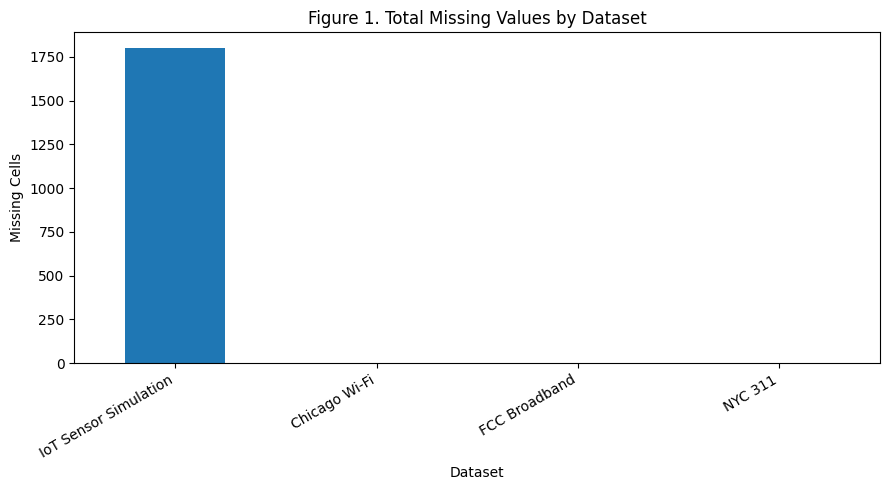

In [54]:
# ============================================================
# Missing Values Bar Chart
# ============================================================

missing_by_dataset = (
    missing_all.groupby("dataset")["missing_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
missing_by_dataset.plot(kind="bar")
plt.title("Figure 1. Total Missing Values by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Missing Cells")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Observation

The missing value results help us decide which fields need cleaning before modeling.  
For example, missing sensor readings should be flagged because they may affect operational monitoring.  
Missing location fields are more serious because location is one of the main keys used to connect the datasets.

## 6. Duplicate Review

Duplicate rows can inflate counts and create false patterns.  
For example, duplicated service requests may make one location look like it has more problems than it really does.

In [55]:
# ============================================================
# Duplicate Review
# ============================================================

dup_summary = pd.DataFrame([
    {
        "dataset": name,
        "total_rows": df.shape[0],
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_pct": round(df.duplicated().mean() * 100, 2)
    }
    for name, df in datasets.items()
])

nu_style_table(dup_summary, "Table 5. Duplicate Row Summary")

,dataset,total_rows,duplicate_rows,duplicate_pct
0,IoT Sensor Simulation,5000,0,0.000000
1,NYC 311,5000,0,0.000000
2,FCC Broadband,5000,0,0.000000
3,Chicago Wi-Fi,5000,0,0.000000


## 7. Sensitive Data and PII Review

This step is very important for MSDS 485.  
The goal is to identify fields that may need masking, restricted access, or retention rules.

The strongest PII risk appears in:

- NYC 311: caller name, phone number, incident address  
- Chicago Wi-Fi: device MAC address, user ID, email, IP address

In [56]:
# ============================================================
# PII and Sensitivity Classification
# ============================================================

pii_inventory = pd.DataFrame([
    {
        "dataset": "NYC 311",
        "field": "pii_caller_name",
        "data_category": "Direct personal identifier",
        "sensitivity_level": "Restricted",
        "recommended_control": "Mask or remove before analyst access"
    },
    {
        "dataset": "NYC 311",
        "field": "pii_phone",
        "data_category": "Direct personal identifier",
        "sensitivity_level": "Restricted",
        "recommended_control": "Mask; keep only if legally needed"
    },
    {
        "dataset": "NYC 311",
        "field": "incident_address",
        "data_category": "Location-linked personal data",
        "sensitivity_level": "Confidential",
        "recommended_control": "Aggregate to ZIP or borough for most analysis"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "field": "device_mac",
        "data_category": "Device identifier",
        "sensitivity_level": "Restricted",
        "recommended_control": "Hash or tokenize"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "field": "pii_user_id",
        "data_category": "User identifier",
        "sensitivity_level": "Restricted",
        "recommended_control": "Hash or tokenize"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "field": "pii_email",
        "data_category": "Direct personal identifier",
        "sensitivity_level": "Restricted",
        "recommended_control": "Mask or remove"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "field": "ip_address",
        "data_category": "Network identifier",
        "sensitivity_level": "Confidential",
        "recommended_control": "Mask last octet or tokenize"
    },
    {
        "dataset": "IoT Sensor Simulation",
        "field": "latitude / longitude",
        "data_category": "Location data",
        "sensitivity_level": "Internal",
        "recommended_control": "Use zone-level aggregation when possible"
    },
    {
        "dataset": "FCC Broadband",
        "field": "census_block",
        "data_category": "Small-area infrastructure data",
        "sensitivity_level": "Internal",
        "recommended_control": "Use for equity analysis; avoid individual claims"
    },
])

nu_style_table(pii_inventory, "Table 6. Initial PII and Sensitivity Inventory")

,dataset,field,data_category,sensitivity_level,recommended_control
0,NYC 311,pii_caller_name,Direct personal identifier,Restricted,Mask or remove before analyst access
1,NYC 311,pii_phone,Direct personal identifier,Restricted,Mask; keep only if legally needed
2,NYC 311,incident_address,Location-linked personal data,Confidential,Aggregate to ZIP or borough for most analysis
3,Chicago Wi-Fi,device_mac,Device identifier,Restricted,Hash or tokenize
4,Chicago Wi-Fi,pii_user_id,User identifier,Restricted,Hash or tokenize
5,Chicago Wi-Fi,pii_email,Direct personal identifier,Restricted,Mask or remove
6,Chicago Wi-Fi,ip_address,Network identifier,Confidential,Mask last octet or tokenize
7,IoT Sensor Simulation,latitude / longitude,Location data,Internal,Use zone-level aggregation when possible
8,FCC Broadband,census_block,Small-area infrastructure data,Internal,Use for equity analysis; avoid individual claims


In [57]:
# ============================================================
# Example Masking Functions
# ============================================================

def mask_email(email):
    if pd.isna(email) or "@" not in str(email):
        return np.nan
    name, domain = str(email).split("@", 1)
    return name[:2] + "***@" + domain

def mask_phone(phone):
    if pd.isna(phone):
        return np.nan
    digits = "".join([c for c in str(phone) if c.isdigit()])
    if len(digits) < 4:
        return "***"
    return "***-***-" + digits[-4:]

def mask_ip(ip):
    if pd.isna(ip):
        return np.nan
    parts = str(ip).split(".")
    if len(parts) == 4:
        return ".".join(parts[:3] + ["xxx"])
    return "***"

# Create safe sample views
nyc_311_safe = nyc_311.copy()
nyc_311_safe["pii_phone_masked"] = nyc_311_safe["pii_phone"].apply(mask_phone)
nyc_311_safe["pii_caller_name_masked"] = "Resident_***"
nyc_311_safe["incident_address_masked"] = "Address masked"

chicago_wifi_safe = chicago_wifi.copy()
chicago_wifi_safe["pii_email_masked"] = chicago_wifi_safe["pii_email"].apply(mask_email)
chicago_wifi_safe["ip_address_masked"] = chicago_wifi_safe["ip_address"].apply(mask_ip)
chicago_wifi_safe["device_mac_masked"] = "MAC_***"
chicago_wifi_safe["pii_user_id_masked"] = "USER_***"

nu_style_table(
    nyc_311_safe[["pii_caller_name", "pii_caller_name_masked", "pii_phone", "pii_phone_masked", "incident_address", "incident_address_masked"]].head(),
    "Table 7. Example NYC 311 Masking Preview"
)

,pii_caller_name,pii_caller_name_masked,pii_phone,pii_phone_masked,incident_address,incident_address_masked
0,Resident_1,Resident_***,917-768-6147,***-***-6147,278 Main St,Address masked
1,Resident_2,Resident_***,917-541-3706,***-***-3706,222 Broadway,Address masked
2,Resident_3,Resident_***,917-789-3305,***-***-3305,88 5th Ave,Address masked
3,Resident_4,Resident_***,917-202-5619,***-***-5619,142 Main St,Address masked
4,Resident_5,Resident_***,917-461-3258,***-***-3258,425 Park Ave,Address masked


In [58]:
nu_style_table(
    chicago_wifi_safe[["pii_email", "pii_email_masked", "ip_address", "ip_address_masked", "device_mac", "device_mac_masked", "pii_user_id", "pii_user_id_masked"]].head(),
    "Table 8. Example Chicago Wi-Fi Masking Preview"
)

,pii_email,pii_email_masked,ip_address,ip_address_masked,device_mac,device_mac_masked,pii_user_id,pii_user_id_masked
0,user1@email.com,us***@email.com,10.17.132.9,10.17.132.xxx,38:a1:c7:e6:2b:b8,MAC_***,USR-71153,USER_***
1,user2@email.com,us***@email.com,10.1.110.240,10.1.110.xxx,73:e0:9c:ca:9f:7c,MAC_***,USR-15225,USER_***
2,user3@email.com,us***@email.com,10.80.230.242,10.80.230.xxx,06:d2:03:31:ae:92,MAC_***,USR-99820,USER_***
3,user4@email.com,us***@email.com,10.245.182.47,10.245.182.xxx,90:1b:1d:cd:80:db,MAC_***,USR-33633,USER_***
4,user5@email.com,us***@email.com,10.63.117.143,10.63.117.xxx,d2:af:ec:6f:72:8a,MAC_***,USR-13449,USER_***


## 8. Dataset-Specific EDA

The following sections review each dataset separately.  
The focus is not only statistical analysis. The focus is also governance: quality, privacy, ethics, and legal risk.

### 8.1 IoT Sensor Simulation

This dataset represents smart-city sensors.  
It is useful for traffic, pedestrian flow, energy, water, air quality, noise, and parking analysis.

In [59]:
# ============================================================
# IoT Sensor EDA
# ============================================================

iot_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "unique_sensors",
        "unique_sensor_types",
        "unique_zones",
        "anomaly_rate_pct",
        "average_data_quality_score"
    ],
    "value": [
        iot.shape[0],
        iot.shape[1],
        iot["sensor_id"].nunique(),
        iot["sensor_type"].nunique(),
        iot["zone"].nunique(),
        round(iot["anomaly_flag"].mean() * 100, 2),
        round(iot["data_quality_score"].mean(), 3)
    ]
})

nu_style_table(iot_summary, "Table 9. IoT Sensor Summary")

,metric,value
0,rows,5000.000000
1,columns,20.000000
2,unique_sensors,500.000000
3,unique_sensor_types,8.000000
4,unique_zones,8.000000
5,anomaly_rate_pct,36.480000
6,average_data_quality_score,0.801000


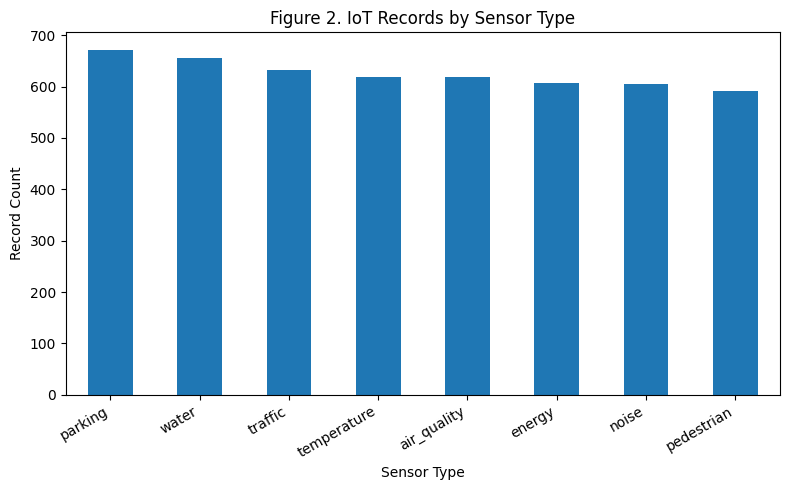

In [60]:
# Sensor type distribution
sensor_type_counts = iot["sensor_type"].value_counts()

plt.figure(figsize=(8, 5))
sensor_type_counts.plot(kind="bar")
plt.title("Figure 2. IoT Records by Sensor Type")
plt.xlabel("Sensor Type")
plt.ylabel("Record Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

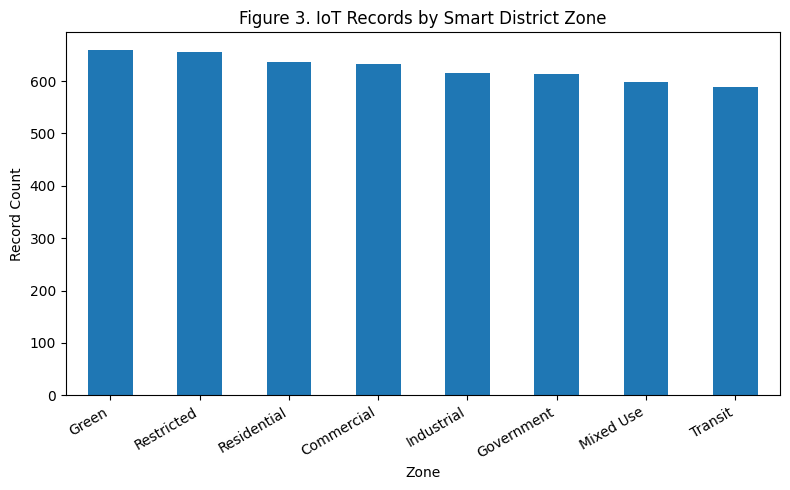

In [61]:
# Zone distribution
zone_counts = iot["zone"].value_counts()

plt.figure(figsize=(8, 5))
zone_counts.plot(kind="bar")
plt.title("Figure 3. IoT Records by Smart District Zone")
plt.xlabel("Zone")
plt.ylabel("Record Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [62]:
# IoT numeric summary
iot_numeric_cols = [
    "temperature_c", "humidity_pct", "traffic_count", "pedestrian_count",
    "energy_kwh", "water_liters", "air_quality_index", "noise_db",
    "parking_occupancy_pct", "battery_pct", "signal_strength_dbm",
    "data_quality_score"
]

iot_numeric_summary = iot[iot_numeric_cols].describe().T.round(2)
nu_style_table(iot_numeric_summary, "Table 10. IoT Numeric Summary")

,count,mean,std,min,25%,50%,75%,max
temperature_c,4721.000000,18.190000,7.900000,-12.150000,12.870000,18.160000,23.450000,48.500000
humidity_pct,4801.000000,57.470000,21.830000,20.000000,38.100000,57.500000,76.300000,95.000000
traffic_count,5000.000000,232.140000,152.790000,-1.000000,97.000000,231.000000,367.000000,500.000000
pedestrian_count,4745.000000,100.410000,57.690000,0.000000,51.000000,101.000000,150.000000,200.000000
energy_kwh,4847.000000,24.990000,14.470000,0.100000,12.390000,25.130000,37.480000,50.000000
water_liters,4790.000000,505.520000,287.970000,0.200000,253.400000,504.250000,755.600000,999.800000
air_quality_index,4753.000000,151.660000,87.400000,0.000000,75.000000,152.000000,227.000000,300.000000
noise_db,4783.000000,70.010000,23.160000,30.000000,49.850000,69.700000,90.450000,110.000000
parking_occupancy_pct,4759.000000,48.700000,28.680000,0.000000,23.900000,48.000000,73.100000,100.000000
battery_pct,5000.000000,52.520000,27.370000,5.000000,28.880000,52.350000,75.900000,100.000000


### IoT governance observation

The IoT dataset has strong value for smart-city operations, but it also creates data quality risks.  
Sensor readings may be missing, noisy, or flagged as anomalies.  
For governance, SignalTrust should keep a data quality score and flag low-quality records before they are used in dashboards.

### 8.2 NYC 311 Service Requests

This dataset represents citizen service requests.  
It is useful because it includes service categories, agencies, status, resolution days, and location fields.  
It also includes PII fields that should be masked before analyst access.

In [63]:
# ============================================================
# NYC 311 EDA
# ============================================================

nyc_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "unique_complaint_types",
        "unique_agencies",
        "unique_boroughs",
        "average_resolution_days",
        "open_rate_pct"
    ],
    "value": [
        nyc_311.shape[0],
        nyc_311.shape[1],
        nyc_311["complaint_type"].nunique(),
        nyc_311["agency"].nunique(),
        nyc_311["borough"].nunique(),
        round(nyc_311["resolution_days"].mean(), 2),
        round((nyc_311["status"].str.lower() == "open").mean() * 100, 2)
    ]
})

nu_style_table(nyc_summary, "Table 11. NYC 311 Summary")

,metric,value
0,rows,5000.000000
1,columns,15.000000
2,unique_complaint_types,10.000000
3,unique_agencies,7.000000
4,unique_boroughs,5.000000
5,average_resolution_days,14.860000
6,open_rate_pct,25.300000


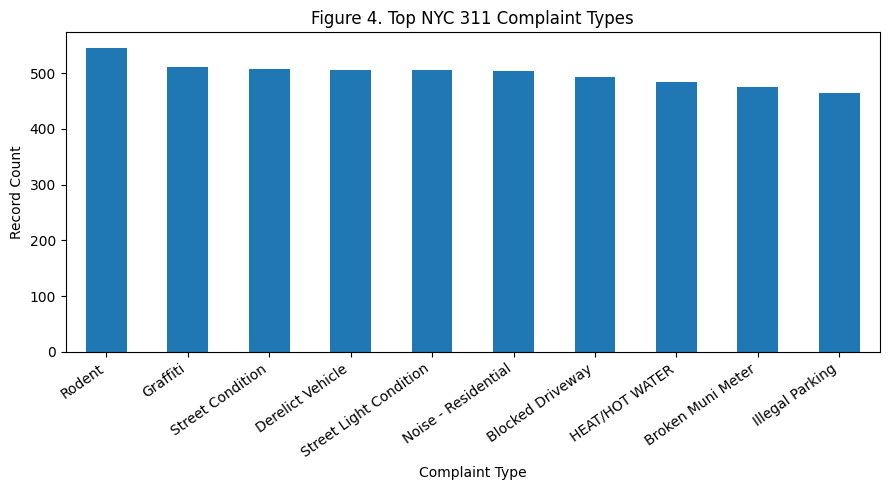

In [64]:
# Complaint type distribution
top_complaints = nyc_311["complaint_type"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_complaints.plot(kind="bar")
plt.title("Figure 4. Top NYC 311 Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Record Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

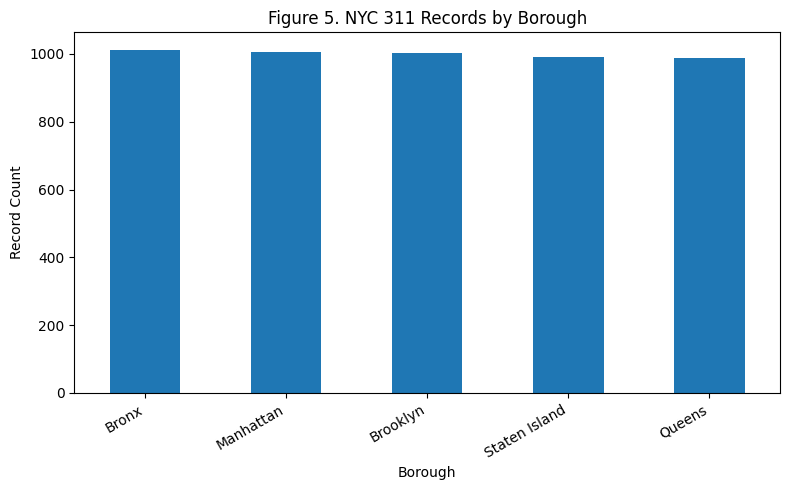

In [65]:
# Borough distribution
borough_counts = nyc_311["borough"].value_counts()

plt.figure(figsize=(8, 5))
borough_counts.plot(kind="bar")
plt.title("Figure 5. NYC 311 Records by Borough")
plt.xlabel("Borough")
plt.ylabel("Record Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [66]:
# Resolution days by complaint type
resolution_by_type = (
    nyc_311.groupby("complaint_type")["resolution_days"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
    .head(10)
)

nu_style_table(resolution_by_type.reset_index(), "Table 12. NYC 311 Resolution Days by Complaint Type")

,complaint_type,count,mean,median,max
0,Noise - Residential,504,15.420000,16.000000,30
1,Rodent,546,15.230000,16.000000,30
2,Street Condition,507,15.060000,15.000000,30
3,Illegal Parking,465,15.050000,15.000000,30
4,HEAT/HOT WATER,485,15.040000,15.000000,30
5,Street Light Condition,505,14.720000,14.000000,30
6,Derelict Vehicle,506,14.690000,15.000000,30
7,Blocked Driveway,494,14.680000,15.000000,30
8,Broken Muni Meter,476,14.490000,14.000000,30
9,Graffiti,512,14.220000,14.000000,30


### NYC 311 governance observation

NYC 311 is one of the strongest datasets for privacy governance because it includes citizen-related fields.  
The main risk is that addresses, phone numbers, and names can expose people.  
For most analytics, SignalTrust should aggregate this data by borough, ZIP code, or complaint type instead of showing individual-level records.

### 8.3 FCC Broadband

This dataset represents telecom infrastructure and broadband access.  
It is useful for equity and bias analysis because it includes technology type, speed, rural areas, low-income areas, and population served.

In [67]:
# ============================================================
# FCC Broadband EDA
# ============================================================

fcc_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "states",
        "providers",
        "technology_types",
        "average_download_mbps",
        "average_upload_mbps",
        "low_income_area_rate_pct",
        "rural_rate_pct"
    ],
    "value": [
        fcc.shape[0],
        fcc.shape[1],
        fcc["state"].nunique(),
        fcc["provider_name"].nunique(),
        fcc["technology_name"].nunique(),
        round(fcc["max_down_mbps"].mean(), 2),
        round(fcc["max_up_mbps"].mean(), 2),
        round(fcc["low_income_area"].mean() * 100, 2),
        round(fcc["rural_flag"].mean() * 100, 2)
    ]
})

nu_style_table(fcc_summary, "Table 13. FCC Broadband Summary")

,metric,value
0,rows,5000.000000
1,columns,17.000000
2,states,15.000000
3,providers,5.000000
4,technology_types,6.000000
5,average_download_mbps,320.250000
6,average_upload_mbps,32.690000
7,low_income_area_rate_pct,19.980000
8,rural_rate_pct,50.980000


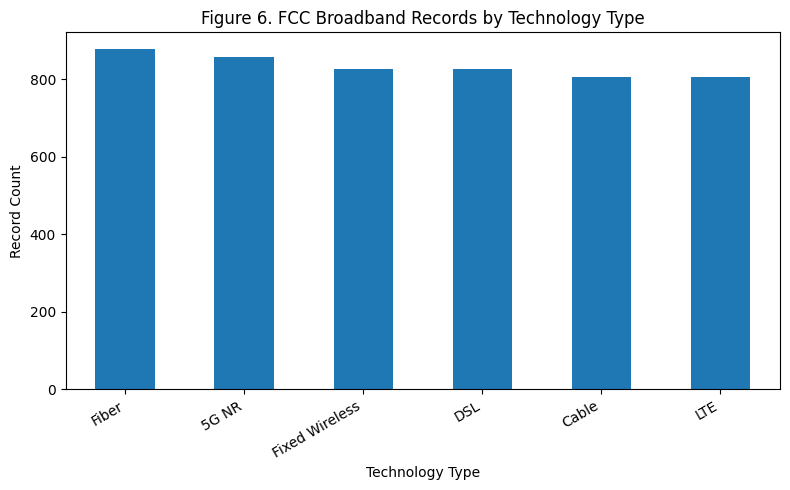

In [68]:
# Technology distribution
tech_counts = fcc["technology_name"].value_counts()

plt.figure(figsize=(8, 5))
tech_counts.plot(kind="bar")
plt.title("Figure 6. FCC Broadband Records by Technology Type")
plt.xlabel("Technology Type")
plt.ylabel("Record Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [69]:
# Average speed by technology type
speed_by_tech = (
    fcc.groupby("technology_name")[["max_down_mbps", "max_up_mbps", "population_served", "median_income"]]
    .mean()
    .round(2)
    .sort_values("max_down_mbps", ascending=False)
)

nu_style_table(speed_by_tech.reset_index(), "Table 14. Average Broadband Speed by Technology Type")

,technology_name,max_down_mbps,max_up_mbps,population_served,median_income
0,Cable,337.440000,34.380000,24654.770000,87680.370000
1,Fixed Wireless,333.740000,33.140000,24955.770000,88133.420000
2,5G NR,320.720000,32.780000,25865.130000,84354.870000
3,Fiber,312.400000,30.760000,24864.770000,86304.040000
4,DSL,310.280000,32.080000,25167.810000,88136.980000
5,LTE,307.480000,33.160000,24852.230000,87741.360000


In [70]:
# Low income vs non-low income speed comparison
equity_speed = (
    fcc.groupby("low_income_area")[["max_down_mbps", "max_up_mbps", "population_served", "median_income"]]
    .mean()
    .round(2)
    .reset_index()
)

equity_speed["area_type"] = equity_speed["low_income_area"].map({0: "Not Low Income", 1: "Low Income"})
equity_speed = equity_speed[["area_type", "max_down_mbps", "max_up_mbps", "population_served", "median_income"]]

nu_style_table(equity_speed, "Table 15. Broadband Equity Comparison")

,area_type,max_down_mbps,max_up_mbps,population_served,median_income
0,Not Low Income,313.920000,32.470000,25111.490000,99506.810000
1,Low Income,345.620000,33.570000,24882.510000,37053.240000


### FCC governance observation

The FCC broadband dataset is useful for fairness and equity questions.  
It can show whether some areas have lower broadband speed, lower infrastructure quality, or fewer people served.  
For SignalTrust, this matters because smart-city benefits should not only go to high-income or high-connectivity areas.

### 8.4 Chicago Wi-Fi

This dataset represents public Wi-Fi sessions.  
It is useful for privacy, access control, and user behavior governance.  
It includes sensitive fields such as device MAC address, user ID, email, and IP address.

In [71]:
# ============================================================
# Chicago Wi-Fi EDA
# ============================================================

wifi_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "unique_sessions",
        "unique_hotspots",
        "unique_locations",
        "average_duration_min",
        "average_data_mb",
        "unique_zip_codes"
    ],
    "value": [
        chicago_wifi.shape[0],
        chicago_wifi.shape[1],
        chicago_wifi["session_id"].nunique(),
        chicago_wifi["hotspot_id"].nunique(),
        chicago_wifi["location_name"].nunique(),
        round(chicago_wifi["duration_min"].mean(), 2),
        round(chicago_wifi["data_mb"].mean(), 2),
        chicago_wifi["zip_code"].nunique()
    ]
})

nu_style_table(wifi_summary, "Table 16. Chicago Wi-Fi Summary")

,metric,value
0,rows,5000.000000
1,columns,15.000000
2,unique_sessions,5000.000000
3,unique_hotspots,300.000000
4,unique_locations,10.000000
5,average_duration_min,90.600000
6,average_data_mb,998.910000
7,unique_zip_codes,90.000000


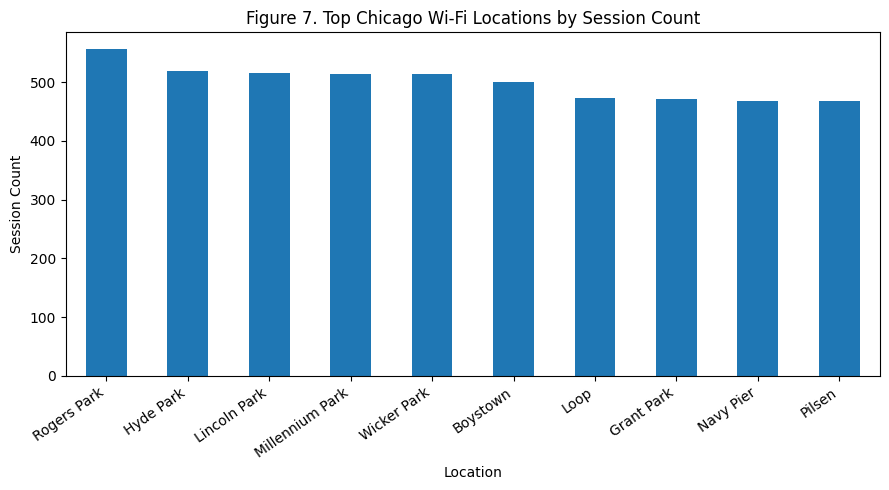

In [72]:
# Top locations by session count
top_wifi_locations = chicago_wifi["location_name"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_wifi_locations.plot(kind="bar")
plt.title("Figure 7. Top Chicago Wi-Fi Locations by Session Count")
plt.xlabel("Location")
plt.ylabel("Session Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [73]:
# Wi-Fi usage by location
wifi_usage_by_location = (
    chicago_wifi.groupby("location_name")[["duration_min", "data_mb"]]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

# Flatten multi-index columns
wifi_usage_by_location.columns = [
    "_".join(col).strip() for col in wifi_usage_by_location.columns.values
]

wifi_usage_by_location = wifi_usage_by_location.sort_values("data_mb_mean", ascending=False).head(10)

nu_style_table(wifi_usage_by_location.reset_index(), "Table 17. Chicago Wi-Fi Usage by Location")

,location_name,duration_min_count,duration_min_mean,duration_min_median,duration_min_max,data_mb_count,data_mb_mean,data_mb_median,data_mb_max
0,Wicker Park,514,88.250000,85.500000,180,514,1063.840000,1081.620000,1999.310000
1,Millennium Park,514,90.610000,91.000000,180,514,1023.740000,1045.680000,1998.350000
2,Navy Pier,468,89.410000,87.000000,180,468,1005.720000,1017.700000,1992.510000
3,Hyde Park,519,88.230000,84.000000,180,519,1003.750000,1012.570000,1999.630000
4,Boystown,501,88.490000,88.000000,180,501,997.250000,995.780000,1981.980000
5,Rogers Park,557,92.890000,92.000000,180,557,994.520000,1027.900000,1999.300000
6,Pilsen,468,95.180000,96.000000,180,468,990.830000,960.520000,1994.050000
7,Loop,473,87.990000,86.000000,179,473,983.300000,989.720000,1999.570000
8,Lincoln Park,515,93.950000,96.000000,180,515,977.590000,985.450000,1993.890000
9,Grant Park,471,90.950000,91.000000,180,471,942.820000,905.040000,1997.190000


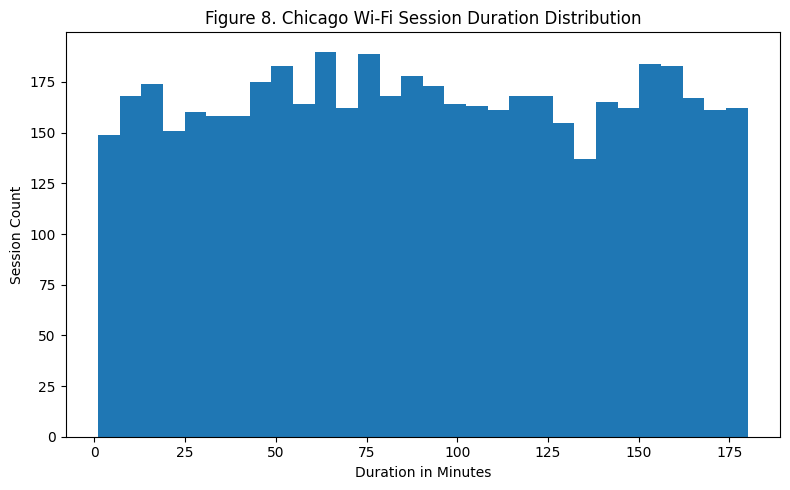

In [74]:
# Session duration distribution
plt.figure(figsize=(8, 5))
chicago_wifi["duration_min"].plot(kind="hist", bins=30)
plt.title("Figure 8. Chicago Wi-Fi Session Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Session Count")
plt.tight_layout()
plt.show()

### Chicago Wi-Fi governance observation

Chicago Wi-Fi is a high-risk privacy dataset because it can describe user sessions and network behavior.  
Even if the project does not use real identities, fields like email, IP address, and device MAC address should be restricted.  
Analysts should usually work with aggregated counts by location, time, or ZIP code.

## 9. Cross-Dataset Governance Map

The datasets come from different systems, so we should not force them into one direct join using personal identifiers.  
Instead, we connect them through shared governance dimensions.

In [75]:
# ============================================================
# Cross-Dataset Governance Mapping
# ============================================================

governance_map = pd.DataFrame([
    {
        "dataset": "IoT Sensor Simulation",
        "source_key": "reading_id",
        "location_fields": "zone, latitude, longitude",
        "time_field": "timestamp",
        "event_type_field": "sensor_type",
        "main_sensitive_fields": "latitude, longitude",
        "recommended_grain": "One sensor reading"
    },
    {
        "dataset": "NYC 311",
        "source_key": "unique_key",
        "location_fields": "borough, incident_zip, incident_address, latitude, longitude",
        "time_field": "created_date",
        "event_type_field": "complaint_type",
        "main_sensitive_fields": "pii_caller_name, pii_phone, incident_address",
        "recommended_grain": "One service request"
    },
    {
        "dataset": "FCC Broadband",
        "source_key": "record_id",
        "location_fields": "state, county, census_block",
        "time_field": "report_date",
        "event_type_field": "technology_name",
        "main_sensitive_fields": "census_block",
        "recommended_grain": "One broadband coverage record"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "source_key": "session_id",
        "location_fields": "location_name, zip_code, latitude, longitude",
        "time_field": "session_start",
        "event_type_field": "ssid / hotspot_id",
        "main_sensitive_fields": "device_mac, pii_user_id, pii_email, ip_address",
        "recommended_grain": "One Wi-Fi session"
    }
])

nu_style_table(governance_map, "Table 18. Dataset Linking and Governance Map")

,dataset,source_key,location_fields,time_field,event_type_field,main_sensitive_fields,recommended_grain
0,IoT Sensor Simulation,reading_id,"zone, latitude, longitude",timestamp,sensor_type,"latitude, longitude",One sensor reading
1,NYC 311,unique_key,"borough, incident_zip, incident_address, latitude, longitude",created_date,complaint_type,"pii_caller_name, pii_phone, incident_address",One service request
2,FCC Broadband,record_id,"state, county, census_block",report_date,technology_name,census_block,One broadband coverage record
3,Chicago Wi-Fi,session_id,"location_name, zip_code, latitude, longitude",session_start,ssid / hotspot_id,"device_mac, pii_user_id, pii_email, ip_address",One Wi-Fi session


### Dataset map

```text
IoT Sensor Simulation ┐
NYC 311              ├── Dim_Source ┐
FCC Broadband        ┤              │
Chicago Wi-Fi        ┘              │
                                      ├── Fact_SmartCity_Events
IoT Sensor Simulation ┐              │
NYC 311              ├── Dim_Location│
FCC Broadband        ┤              │
Chicago Wi-Fi        ┘              │
                                      │
IoT Sensor Simulation ┐              │
NYC 311              ├── Dim_Time    │
FCC Broadband        ┤              │
Chicago Wi-Fi        ┘              │
                                      │
IoT Sensor Simulation ┐              │
NYC 311              ├── Dim_Event_Type
FCC Broadband        ┤
Chicago Wi-Fi        ┘

All datasets also connect to:
Dim_Governance_Classification
```

This design supports privacy because it does not join people across datasets.  
It supports data lineage because every record keeps a source system.

## 10. Initial Data Quality Findings

This table gives a first data quality report.  
It can be used in the Week 4 submission.

In [76]:
# ============================================================
# Data Quality Report
# ============================================================

quality_findings = pd.DataFrame([
    {
        "dataset": "IoT Sensor Simulation",
        "issue": "Some sensor reading fields may have missing values",
        "risk": "Dashboards may show incomplete or misleading readings",
        "recommended_fix": "Flag missing readings, keep data quality score, and avoid deleting records too early"
    },
    {
        "dataset": "NYC 311",
        "issue": "Contains direct PII fields",
        "risk": "Citizen privacy risk if names, phone numbers, or addresses are exposed",
        "recommended_fix": "Mask PII and aggregate location before analyst use"
    },
    {
        "dataset": "FCC Broadband",
        "issue": "Equity fields need careful interpretation",
        "risk": "Wrong conclusions about low-income or rural areas",
        "recommended_fix": "Compare speeds and coverage by area type, and clearly document limitations"
    },
    {
        "dataset": "Chicago Wi-Fi",
        "issue": "Contains user and network identifiers",
        "risk": "Session data may expose user behavior or movement patterns",
        "recommended_fix": "Hash device/user IDs, mask email and IP address, and use RBAC"
    },
    {
        "dataset": "All datasets",
        "issue": "Different locations and time fields",
        "risk": "Data cannot be connected cleanly without standardization",
        "recommended_fix": "Create shared Dim_Location, Dim_Time, Dim_Source, and Dim_Event_Type tables"
    }
])

nu_style_table(quality_findings, "Table 19. Initial Data Quality and Governance Findings")

,dataset,issue,risk,recommended_fix
0,IoT Sensor Simulation,Some sensor reading fields may have missing values,Dashboards may show incomplete or misleading readings,"Flag missing readings, keep data quality score, and avoid deleting records too early"
1,NYC 311,Contains direct PII fields,"Citizen privacy risk if names, phone numbers, or addresses are exposed",Mask PII and aggregate location before analyst use
2,FCC Broadband,Equity fields need careful interpretation,Wrong conclusions about low-income or rural areas,"Compare speeds and coverage by area type, and clearly document limitations"
3,Chicago Wi-Fi,Contains user and network identifiers,Session data may expose user behavior or movement patterns,"Hash device/user IDs, mask email and IP address, and use RBAC"
4,All datasets,Different locations and time fields,Data cannot be connected cleanly without standardization,"Create shared Dim_Location, Dim_Time, Dim_Source, and Dim_Event_Type tables"


## 11. Suggested 3NF Target Tables

Based on the EDA, the first target model should use shared dimension tables and one fact table.

In [77]:
# ============================================================
# 3NF Target Model Summary
# ============================================================

target_model = pd.DataFrame([
    {
        "table_name": "Dim_Source",
        "purpose": "Tracks original dataset and data owner",
        "example_fields": "source_id, dataset_name, source_owner, source_url, update_frequency"
    },
    {
        "table_name": "Dim_Location",
        "purpose": "Standardizes city, ZIP, zone, and coordinates",
        "example_fields": "location_id, city, state, district_or_area, zip_code, latitude, longitude"
    },
    {
        "table_name": "Dim_Time",
        "purpose": "Standardizes all date/time fields",
        "example_fields": "time_id, date, month, quarter, year, day_of_week"
    },
    {
        "table_name": "Dim_Event_Type",
        "purpose": "Groups records into sensor, complaint, Wi-Fi, or broadband events",
        "example_fields": "event_type_id, event_category, event_name, description"
    },
    {
        "table_name": "Dim_Governance_Classification",
        "purpose": "Classifies fields by sensitivity and access rule",
        "example_fields": "classification_id, field_name, sensitivity_level, masking_required, access_role"
    },
    {
        "table_name": "Fact_SmartCity_Events",
        "purpose": "Main governed event table",
        "example_fields": "event_id, source_id, location_id, time_id, event_type_id, event_value, risk_category"
    }
])

nu_style_table(target_model, "Table 20. Suggested 3NF Target Tables")

,table_name,purpose,example_fields
0,Dim_Source,Tracks original dataset and data owner,"source_id, dataset_name, source_owner, source_url, update_frequency"
1,Dim_Location,"Standardizes city, ZIP, zone, and coordinates","location_id, city, state, district_or_area, zip_code, latitude, longitude"
2,Dim_Time,Standardizes all date/time fields,"time_id, date, month, quarter, year, day_of_week"
3,Dim_Event_Type,"Groups records into sensor, complaint, Wi-Fi, or broadband events","event_type_id, event_category, event_name, description"
4,Dim_Governance_Classification,Classifies fields by sensitivity and access rule,"classification_id, field_name, sensitivity_level, masking_required, access_role"
5,Fact_SmartCity_Events,Main governed event table,"event_id, source_id, location_id, time_id, event_type_id, event_value, risk_category"


## 12. EDA Conclusion

The four selected datasets are strong enough for the SignalTrust project.  
They support the main class topics: data quality, data masking, data classification, RBAC, bias analysis, and data lineage.

The most important governance finding is that the datasets should be connected through governance dimensions, not personal identifiers.  
This protects privacy and still allows useful analysis.

### Key next steps

1. Clean missing values and standardize dates.  
2. Mask PII fields in NYC 311 and Chicago Wi-Fi.  
3. Create shared dimension tables for source, location, time, event type, and classification.  
4. Load the clean datasets into a database.  
5. Use the data quality report as evidence for Week 4.

## 13. Combine All Datasets into One Governed Smart-City Event Table

The four datasets should not be merged side by side because they do not share the same person ID, sensor ID, or location ID. Instead, we combine them using a **governed event model**.

This approach is better for the SignalTrust use case because it connects all data sources through common governance fields:

- source system
- event type
- city or location area
- event date/time
- event value
- event unit
- privacy flag
- risk category
- governance purpose

This also supports privacy because the model does **not** try to link citizens, Wi-Fi users, and sensor records to the same person.

In [78]:
# ============================================================
# Helper Functions for the Combined Event Table
# ============================================================

def safe_series(df, column_name, default_value=None):
    """Return a column if it exists; otherwise return a default value series."""
    if column_name in df.columns:
        return df[column_name]
    return pd.Series([default_value] * len(df), index=df.index)


def build_combined_events(iot, nyc_311, fcc, chicago_wifi):
    """Build one governed event table from all four SignalTrust datasets."""
    event_frames = []

    # 1. IoT Sensor Simulation
    iot_events = pd.DataFrame({
        "source_name": "IoT Sensor Simulation",
        "source_record_id": safe_series(iot, "reading_id"),
        "event_type": safe_series(iot, "sensor_type"),
        "event_category": "IoT Sensor Reading",
        "city": "Smart District Simulation",
        "location_area": safe_series(iot, "zone"),
        "zip_code": pd.NA,
        "latitude": safe_series(iot, "latitude"),
        "longitude": safe_series(iot, "longitude"),
        "event_datetime": safe_series(iot, "timestamp"),
        "event_value": safe_series(iot, "data_quality_score"),
        "event_unit": "data_quality_score",
        "risk_category": "Operational / Infrastructure",
        "pii_flag": "No",
        "sensitivity_level": "Internal",
        "governance_use": "IoT data quality, anomaly review, and infrastructure monitoring"
    })
    event_frames.append(iot_events)

    # 2. NYC 311 Service Requests
    nyc_events = pd.DataFrame({
        "source_name": "NYC 311 Service Requests",
        "source_record_id": safe_series(nyc_311, "unique_key"),
        "event_type": safe_series(nyc_311, "complaint_type"),
        "event_category": "Citizen Service Request",
        "city": "New York",
        "location_area": safe_series(nyc_311, "borough"),
        "zip_code": safe_series(nyc_311, "incident_zip"),
        "latitude": safe_series(nyc_311, "latitude"),
        "longitude": safe_series(nyc_311, "longitude"),
        "event_datetime": safe_series(nyc_311, "created_date"),
        "event_value": safe_series(nyc_311, "resolution_days"),
        "event_unit": "resolution_days",
        "risk_category": "Public Service / Privacy",
        "pii_flag": "Yes",
        "sensitivity_level": "Restricted",
        "governance_use": "PII masking, data quality, complaint analysis, and service response review"
    })
    event_frames.append(nyc_events)

    # 3. FCC Broadband
    fcc_events = pd.DataFrame({
        "source_name": "FCC Broadband",
        "source_record_id": safe_series(fcc, "record_id"),
        "event_type": safe_series(fcc, "technology_name"),
        "event_category": "Broadband Infrastructure",
        "city": "National Broadband Area",
        "location_area": safe_series(fcc, "state"),
        "zip_code": pd.NA,
        "latitude": pd.NA,
        "longitude": pd.NA,
        "event_datetime": safe_series(fcc, "report_date"),
        "event_value": safe_series(fcc, "max_down_mbps"),
        "event_unit": "max_download_mbps",
        "risk_category": "Equity / Infrastructure",
        "pii_flag": "No",
        "sensitivity_level": "Public / Internal",
        "governance_use": "Broadband access, digital divide, and bias analysis"
    })
    event_frames.append(fcc_events)

    # 4. Chicago Wi-Fi
    wifi_events = pd.DataFrame({
        "source_name": "Chicago Wi-Fi",
        "source_record_id": safe_series(chicago_wifi, "session_id"),
        "event_type": "Wi-Fi Session",
        "event_category": "Public Connectivity Session",
        "city": "Chicago",
        "location_area": safe_series(chicago_wifi, "location_name"),
        "zip_code": safe_series(chicago_wifi, "zip_code"),
        "latitude": safe_series(chicago_wifi, "latitude"),
        "longitude": safe_series(chicago_wifi, "longitude"),
        "event_datetime": safe_series(chicago_wifi, "session_start"),
        "event_value": safe_series(chicago_wifi, "duration_min"),
        "event_unit": "duration_minutes",
        "risk_category": "Connectivity / Privacy",
        "pii_flag": "Yes",
        "sensitivity_level": "Restricted",
        "governance_use": "Wi-Fi privacy, RBAC, session governance, and masking"
    })
    event_frames.append(wifi_events)

    combined = pd.concat(event_frames, ignore_index=True)
    combined.insert(0, "event_id", range(1, len(combined) + 1))
    combined["event_datetime"] = pd.to_datetime(combined["event_datetime"], errors="coerce")
    combined["event_date"] = combined["event_datetime"].dt.date
    combined["event_year"] = combined["event_datetime"].dt.year
    combined["event_month"] = combined["event_datetime"].dt.month
    return combined


fact_smartcity_events = build_combined_events(iot, nyc_311, fcc, chicago_wifi)

print(f"Combined table shape: {fact_smartcity_events.shape[0]:,} rows x {fact_smartcity_events.shape[1]:,} columns")
fact_smartcity_events.head()


Combined table shape: 20,000 rows x 20 columns


,event_id,source_name,source_record_id,event_type,event_category,city,location_area,zip_code,latitude,longitude,event_datetime,event_value,event_unit,risk_category,pii_flag,sensitivity_level,governance_use,event_date,event_year,event_month
0,1,IoT Sensor Simulation,IOT-0000001,water,IoT Sensor Reading,Smart District Simulation,Commercial,<NA>,40.724080,-73.877999,2024-12-30 07:08:21,0.71,data_quality_score,Operational / Infrastructure,No,Internal,"IoT data quality, anomaly review, and infrastr...",2024-12-30,2024,12
1,2,IoT Sensor Simulation,IOT-0000002,pedestrian,IoT Sensor Reading,Smart District Simulation,Commercial,<NA>,40.623212,-74.161872,2023-12-16 15:14:18,0.75,data_quality_score,Operational / Infrastructure,No,Internal,"IoT data quality, anomaly review, and infrastr...",2023-12-16,2023,12
2,3,IoT Sensor Simulation,IOT-0000003,traffic,IoT Sensor Reading,Smart District Simulation,Mixed Use,<NA>,40.630536,-74.129719,2024-05-31 07:34:55,0.81,data_quality_score,Operational / Infrastructure,No,Internal,"IoT data quality, anomaly review, and infrastr...",2024-05-31,2024,5
3,4,IoT Sensor Simulation,IOT-0000004,energy,IoT Sensor Reading,Smart District Simulation,Green,<NA>,40.766184,-73.899160,2023-08-14 19:55:20,0.97,data_quality_score,Operational / Infrastructure,No,Internal,"IoT data quality, anomaly review, and infrastr...",2023-08-14,2023,8
4,5,IoT Sensor Simulation,IOT-0000005,noise,IoT Sensor Reading,Smart District Simulation,Government,<NA>,40.543837,-73.950589,2023-05-08 03:11:37,0.72,data_quality_score,Operational / Infrastructure,No,Internal,"IoT data quality, anomaly review, and infrastr...",2023-05-08,2023,5


### Combined Dataset Inventory

This table checks whether the combined event table is balanced and useful for governance analysis.

In [79]:
combined_inventory = (
    fact_smartcity_events
    .groupby(["source_name", "event_category", "pii_flag", "sensitivity_level", "risk_category"], dropna=False)
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

combined_inventory

,source_name,event_category,pii_flag,sensitivity_level,risk_category,record_count
0,Chicago Wi-Fi,Public Connectivity Session,Yes,Restricted,Connectivity / Privacy,5000
1,FCC Broadband,Broadband Infrastructure,No,Public / Internal,Equity / Infrastructure,5000
2,IoT Sensor Simulation,IoT Sensor Reading,No,Internal,Operational / Infrastructure,5000
3,NYC 311 Service Requests,Citizen Service Request,Yes,Restricted,Public Service / Privacy,5000


### Combined EDA Checks

These checks help us understand the combined governance table, including missing values, source distribution, event types, PII exposure, and sensitivity levels.

In [80]:
# Missing values in the combined event table
combined_missing = (
    fact_smartcity_events.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
combined_missing["missing_pct"] = (combined_missing["missing_count"] / len(fact_smartcity_events) * 100).round(2)
combined_missing.sort_values("missing_pct", ascending=False).head(20)


,column,missing_count,missing_pct
7,zip_code,10000,50.0
8,latitude,5000,25.0
9,longitude,5000,25.0
0,event_id,0,0.0
3,event_type,0,0.0
2,source_record_id,0,0.0
1,source_name,0,0.0
4,event_category,0,0.0
6,location_area,0,0.0
5,city,0,0.0


In [81]:
# Source distribution
source_counts = fact_smartcity_events["source_name"].value_counts()
source_counts


,count
source_name,
IoT Sensor Simulation,5000
NYC 311 Service Requests,5000
FCC Broadband,5000
Chicago Wi-Fi,5000


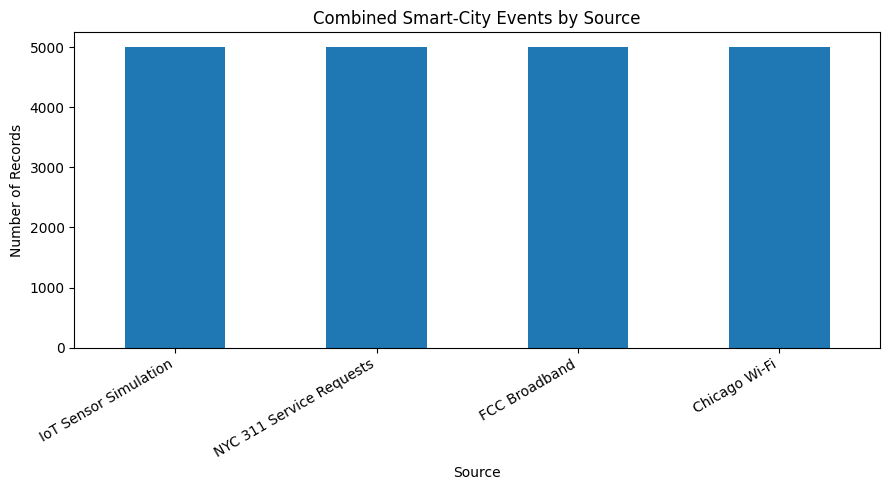

In [82]:
plt.figure(figsize=(9, 5))
source_counts.plot(kind="bar")
plt.title("Combined Smart-City Events by Source")
plt.xlabel("Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [83]:
# Governance risk distribution
risk_counts = fact_smartcity_events["risk_category"].value_counts()
risk_counts


,count
risk_category,
Operational / Infrastructure,5000
Public Service / Privacy,5000
Equity / Infrastructure,5000
Connectivity / Privacy,5000


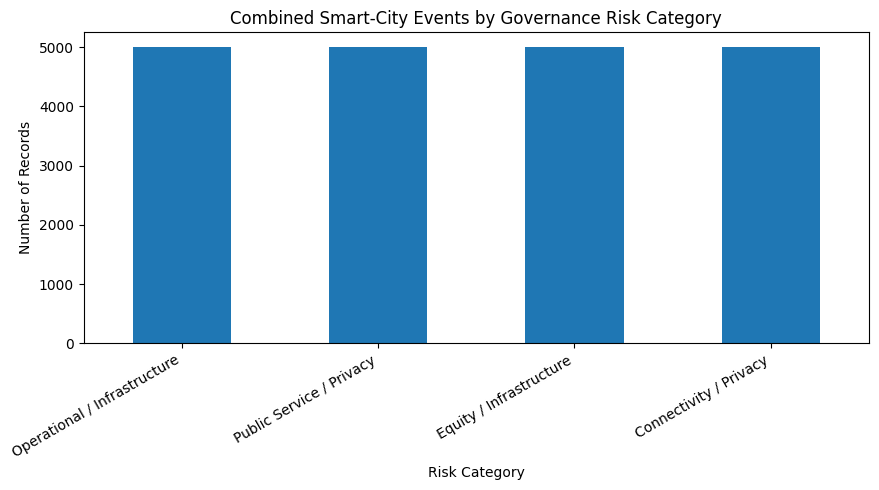

In [84]:
plt.figure(figsize=(9, 5))
risk_counts.plot(kind="bar")
plt.title("Combined Smart-City Events by Governance Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [85]:
# PII and sensitivity distribution
pii_sensitivity = (
    fact_smartcity_events
    .groupby(["pii_flag", "sensitivity_level"], dropna=False)
    .size()
    .reset_index(name="record_count")
)
pii_sensitivity


,pii_flag,sensitivity_level,record_count
0,No,Internal,5000
1,No,Public / Internal,5000
2,Yes,Restricted,10000


In [86]:
# Time range by source
time_range_by_source = (
    fact_smartcity_events
    .groupby("source_name")
    .agg(
        min_event_datetime=("event_datetime", "min"),
        max_event_datetime=("event_datetime", "max"),
        records=("event_id", "count")
    )
    .reset_index()
)
time_range_by_source


,source_name,min_event_datetime,max_event_datetime,records
0,Chicago Wi-Fi,2023-01-01 03:40:44,2024-12-30 22:28:56,5000
1,FCC Broadband,2023-01-01 00:00:00,2024-12-30 00:00:00,5000
2,IoT Sensor Simulation,2023-01-01 11:51:50,2024-12-30 18:01:55,5000
3,NYC 311 Service Requests,2023-01-01 02:21:29,2024-12-30 21:56:33,5000


### Data Governance Interpretation

The combined table shows that the datasets can work together as one governed smart-city data system. The table does not create a risky personal identity link between people in different datasets. Instead, it connects records by source, time, location area, event category, and risk category.

This is important for SignalTrust because the project is not only about analytics. It is also about trust, privacy, and legal control. For example, NYC 311 and Chicago Wi-Fi have direct privacy risk because they include personal or user-level fields. The IoT sensor data has operational risk because it supports infrastructure decisions. The FCC broadband data supports equity and bias analysis because it shows access differences across areas.

### Save the Combined Dataset

This saves the combined table back to the same Google Drive folder. The file can be used later for data classification, RBAC, masking, data lineage, and dashboard work.

In [87]:
# Save combined governed event table
combined_output_path = DATA_DIR / "fact_smartcity_events_combined.csv"
fact_smartcity_events.to_csv(combined_output_path, index=False)

print(f"Saved combined dataset to: {combined_output_path}")


Saved combined dataset to: /content/drive/MyDrive/MSDS 485 - Data Governance, Ethics, and Law/Final project/485-project-csv-files/fact_smartcity_events_combined.csv


## 14. Updated Initial 3NF Target Model

After combining the datasets into one governed event table, the target model can be organized like this:

**Dim_Source**  
Stores dataset name, owner, source URL, and update frequency.

**Dim_Location**  
Stores city, state, ZIP code, latitude, longitude, district, and zone type.

**Dim_Time**  
Stores date, month, quarter, year, and day of week.

**Dim_Event_Type**  
Stores event category and event type, such as IoT sensor reading, 311 complaint, Wi-Fi session, or broadband infrastructure.

**Dim_Governance_Classification**  
Stores PII flag, sensitivity level, masking rule, access role, and retention rule.

**Fact_SmartCity_Events**  
Stores each event with foreign keys to source, location, time, event type, and governance classification.

This structure is better than one large raw table because it supports auditability, lineage, privacy control, and clean reporting.

## 15. Source Notes and Bibliography — Chicago Style

### Notes

1. City of New York, “311 Service Requests from 2020 to Present,” NYC Open Data.  
2. Federal Communications Commission, “Broadband Coverage and Technology Data,” FCC broadband data source.  
3. City of Chicago, “Chicago Wi-Fi Usage Data,” Chicago Data Portal.  
4. Synthetic Smart City Infrastructure Sensor Dataset, Kaggle dataset used for educational simulation.  
5. Northwestern University, MSDS 485 course case, “Telecom: SignalTrust — The Smart-City Backbone.”

### Bibliography

City of Chicago. “Chicago Wi-Fi Usage Data.” *Chicago Data Portal*. Accessed for MSDS 485 project work.

City of New York. “311 Service Requests from 2020 to Present.” *NYC Open Data*. Accessed for MSDS 485 project work.

Federal Communications Commission. “Broadband Coverage and Technology Data.” *FCC Broadband Data*. Accessed for MSDS 485 project work.

Kaggle. “Synthetic Smart City Infrastructure Sensor Dataset.” Accessed for MSDS 485 project work.

Northwestern University. “Telecom: SignalTrust — The Smart-City Backbone.” MSDS 485 Data Governance, Ethics, and Law course case.